# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [62]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

df = pd.read_csv("m1-09-assessment.csv", parse_dates=["date"])
df = df.set_index("date")

# TODO: Show head/tail and check info

print(f"{df.head()}\n\n\n{df.tail()}")


              city  avg_temp_c  humidity_pct   pm25
date                                               
2023-01-01  London       -0.79         62.93  39.39
2023-01-02  London        1.31         61.49  32.41
2023-01-03  London        1.46         76.51  30.61
2023-01-04  London       -0.57         58.05  30.71
2023-01-05  London       -1.13         36.30  20.70


              city  avg_temp_c  humidity_pct   pm25
date                                               
2023-06-25  Madrid         NaN         72.04   5.00
2023-06-26  Madrid       28.44         74.19   5.00
2023-06-27  Madrid       26.41         64.41   5.24
2023-06-28  Madrid       27.53         86.47  14.86
2023-06-29  Madrid       24.22         74.33    NaN


## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [63]:
# TODO: data inspection
df.info()
df.describe()
df.isna().sum()

# TODO: clean pm25
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

# TODO: handle missing values in pm25 and justify in markdown
df['pm25'] = df['pm25'].interpolate(method='linear')



<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), str(1)
memory usage: 35.2 KB


## Part B: Required Analysis (TODOs)

- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: choose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

In [64]:
# - data quality by city

invalid_mask = df['pm25'].isna() | (df['pm25'] <= 0) #masking city with invalid/missing pm25

quality = (
    df.assign(invalid=invalid_mask)
      .groupby('city')['invalid'] #we output values with the help of our mask
      .mean()
      .sort_values(ascending=False)
      .reset_index(name='invalid_pct') #invalid percentage
)

quality.head()

,city,invalid_pct
0,Berlin,0.0
1,London,0.0
2,Madrid,0.0
3,Paris,0.0
4,Warsaw,0.0


In [65]:
# - rolling averages per city

window_size = 7

df = df.sort_values(['city', 'date'])

df['pm25_7d_avg'] = (
    df.groupby('city')['pm25']
      .rolling(window=window_size, min_periods=3)
      .mean()
      .reset_index(level=0, drop=True)
)

df

# 'We define a window size for rolling and then create a column for given window size average, group values and calculate the'
# 'mean, in the end resetting the index.'


,city,avg_temp_c,humidity_pct,pm25,pm25_7d_avg
date,,,,,
2023-01-01,Berlin,-4.06,48.05,38.44,NaN
2023-01-02,Berlin,-2.81,35.00,27.91,NaN
2023-01-03,Berlin,-4.49,61.95,37.33,34.560000
2023-01-04,Berlin,-6.80,66.30,33.19,34.217500
2023-01-05,Berlin,-3.20,68.82,37.20,34.814000
...,...,...,...,...,...
2023-06-25,Warsaw,16.05,66.84,19.53,10.425714
2023-06-26,Warsaw,18.58,61.21,12.61,11.087143
2023-06-27,Warsaw,14.78,78.25,5.69,10.380000


In [66]:
# - percentile-based event counts

threshold = df['pm25'].quantile(.9) #defining threshold above 90%

df['high_pollution'] = df['pm25'] >= threshold #creating new collumn with our mask

events = (
    df.groupby('city')['high_pollution']
      .sum()
      .reset_index(name='high_pollution_days') #resetting index helps to avoid messy values
)

events

# 'In the end we create a dataframe with city names and corresponding pollution days'

,city,high_pollution_days
0,Berlin,13
1,London,18
2,Madrid,21
3,Paris,17
4,Warsaw,21


In [67]:
# - volatility comparison

cities = ['London', 'Madrid']

volatility = (
    df[df['city'].isin(cities)]
                 .groupby('city')['pm25']
                 .agg(['mean','std'])
)


volatility['coefficient_variation'] = volatility['std'] / volatility['mean']

volatility

# 'Used Coefficient of Variation as my metric because it is scale independent and compares relative to pollution level'

,mean,std,coefficient_variation
city,,,
London,24.331472,12.206188,0.501663
Madrid,24.270889,11.495844,0.473647


In [68]:

# - pivot table by month and city

pivot_pm25 = pd.pivot_table(
    df,
    values='pm25',
    index=df.index.to_period('M'), #defining months as rows not exact dates by resampling
    columns='city',
    aggfunc='mean'
)

pivot_pm25

city,Berlin,London,Madrid,Paris,Warsaw
date,,,,,
2023-01,33.025323,33.275806,33.353226,34.625806,37.239032
2023-02,33.163036,34.102321,34.766964,34.024643,34.020357
2023-03,29.030968,29.737742,30.219677,26.736774,27.751613
2023-04,22.134167,24.864333,22.098833,23.100000,20.749333
2023-05,15.402742,14.406452,14.966129,13.840000,14.520323
2023-06,10.074655,9.615517,10.262414,9.280345,9.655862


## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

In [69]:
# TODO: aggregation tasks
# avg_pm25_by_city = ...
# monthly_avg_pm25 = ...
# hottest_day_per_city = ...

In [70]:
avg_pm25_by_city = (
    df.groupby('city')['pm25']
      .mean()
      .reset_index(name='avg_pm25')
)

avg_pm25_by_city


,city,avg_pm25
0,Berlin,23.811028
1,London,24.331472
2,Madrid,24.270889
3,Paris,23.589444
4,Warsaw,23.999500


In [71]:
monthly_avg_pm25 = pivot_pm25

monthly_avg_pm25

#same task as 5 in B


city,Berlin,London,Madrid,Paris,Warsaw
date,,,,,
2023-01,33.025323,33.275806,33.353226,34.625806,37.239032
2023-02,33.163036,34.102321,34.766964,34.024643,34.020357
2023-03,29.030968,29.737742,30.219677,26.736774,27.751613
2023-04,22.134167,24.864333,22.098833,23.100000,20.749333
2023-05,15.402742,14.406452,14.966129,13.840000,14.520323
2023-06,10.074655,9.615517,10.262414,9.280345,9.655862


In [72]:
hottest_day_per_city = df.groupby('city')['avg_temp_c'].max()

hottest_day_per_city


city
Berlin    22.13
London    21.80
Madrid    30.39
Paris     23.25
Warsaw    20.89
Name: avg_temp_c, dtype: float64

## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

In [73]:
# TODO: plotting section
# plt.figure(...)
# plt.plot(...)
# plt.bar(...)
# plt.show()

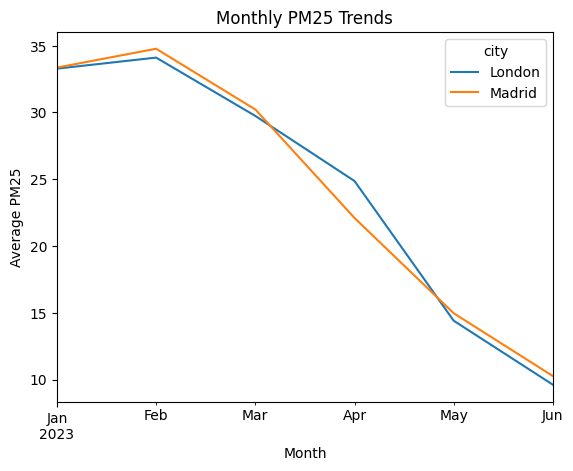

In [74]:
import matplotlib.pyplot as plt


pivot_pm25[['London', 'Madrid']].plot()

plt.xlabel('Month')
plt.ylabel('Average PM25')
plt.title('Monthly PM25 Trends')
plt.show()

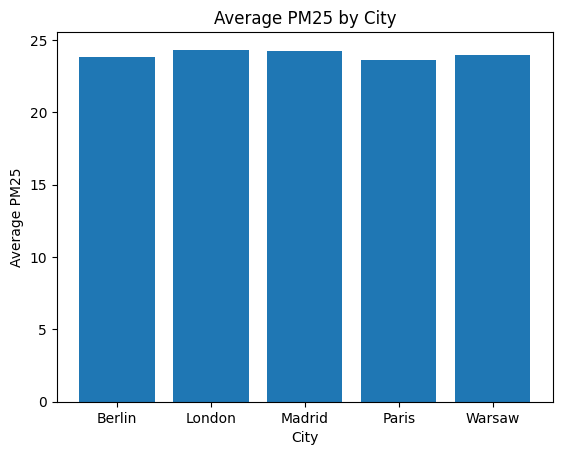

In [75]:
avg_pm25_by_city_plot = df.groupby('city')['pm25'].mean() #i defined a new 'avg" because old one kept getting me error :D (i guess because of no indexes)

plt.figure()
plt.bar(avg_pm25_by_city_plot.index, avg_pm25_by_city_plot.values)

plt.xlabel('City')
plt.ylabel('Average PM25')
plt.title('Average PM25 by City')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_23852\678856529.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=cities)


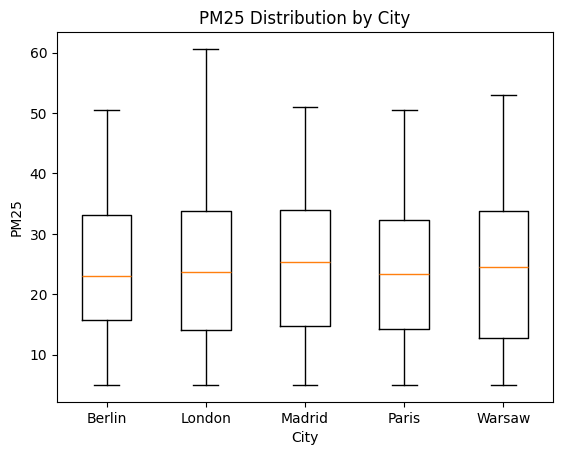

In [ ]:
cities = df['city'].unique()

data = [df[df['city'] == city]['pm25'] for city in cities]

plt.figure()
plt.boxplot(data, labels=cities)
plt.xlabel('City')
plt.ylabel('PM25')
plt.title('PM25 Distribution by City')
plt.show()

## Part E: Interpretation Questions (TODOs)

Write short answers here:

1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
2. How does missing or invalid data affect your confidence in the results?
3. Does temperature appear related to pm25 in your analysis? Explain briefly.
4. What is one limitation of using daily averages for air-quality policy decisions?
5. If you had one more dataset to improve this analysis, what would it be and why?

1. London. We can see it on our avg_pm25_by_city dataframe. (Highest average = persistent high pm25 levels)
2. Missing or invalid readings reduce confidence because averages or trends may be biased.
3. There is a strong negative correlation between temperature and PM25, meaning that as temperatures rise, air pollution levels typically decrease.
4. Daily averages can mask short-term spikes that are harmful. Policies based on averages may fail to protect public health during peak pollution hours.
5. Including wind speed and its direction would help, it will be easier to understand the cause of high pollution better as pm25 is affected by local sources.

In [77]:
temperature_pm_relation = df[['avg_temp_c','pm25']].copy()

temperature_pm_relation['pm25_per_temp'] = temperature_pm_relation['pm25'] / temperature_pm_relation['avg_temp_c']

temperature_pm_relation

,avg_temp_c,pm25,pm25_per_temp
date,,,
2023-01-01,-4.06,38.44,-9.467980
2023-01-02,-2.81,27.91,-9.932384
2023-01-03,-4.49,37.33,-8.314031
2023-01-04,-6.80,33.19,-4.880882
2023-01-05,-3.20,37.20,-11.625000
...,...,...,...
2023-06-25,16.05,19.53,1.216822
2023-06-26,18.58,12.61,0.678687
2023-06-27,14.78,5.69,0.384980
